Returns loaded : (10330, 117)
Date range     : 1989-07-31 -> 2026-03-13

Signal dataframe: (10285, 13)
Date range      : 1990-01-02 -> 2026-03-13

Regime distribution:
regime
TRANSITIONAL        4483
EASING CYCLE        1820
TIGHTENING CYCLE     868
FINANCIAL CRISIS     677
RISK-ON              676
GOLDILOCKS           436
RISK-OFF             428
RECOVERY             414

SEQUENTIAL SIGNAL STATISTICS — Full Period

  Asia → Europe (same day)
    n=10,284  corr=+0.408  R²=0.166  beta=0.512  dir_accuracy=62.3%

  Europe → US (same day)
    n=10,284  corr=+0.544  R²=0.296  beta=0.513  dir_accuracy=68.9%

  US → Asia next day
    n=10,283  corr=+0.425  R²=0.181  beta=0.360  dir_accuracy=61.8%

  Europe → US (1D lag)
    n=10,283  corr=-0.029  R²=0.001  beta=-0.027  dir_accuracy=49.3%


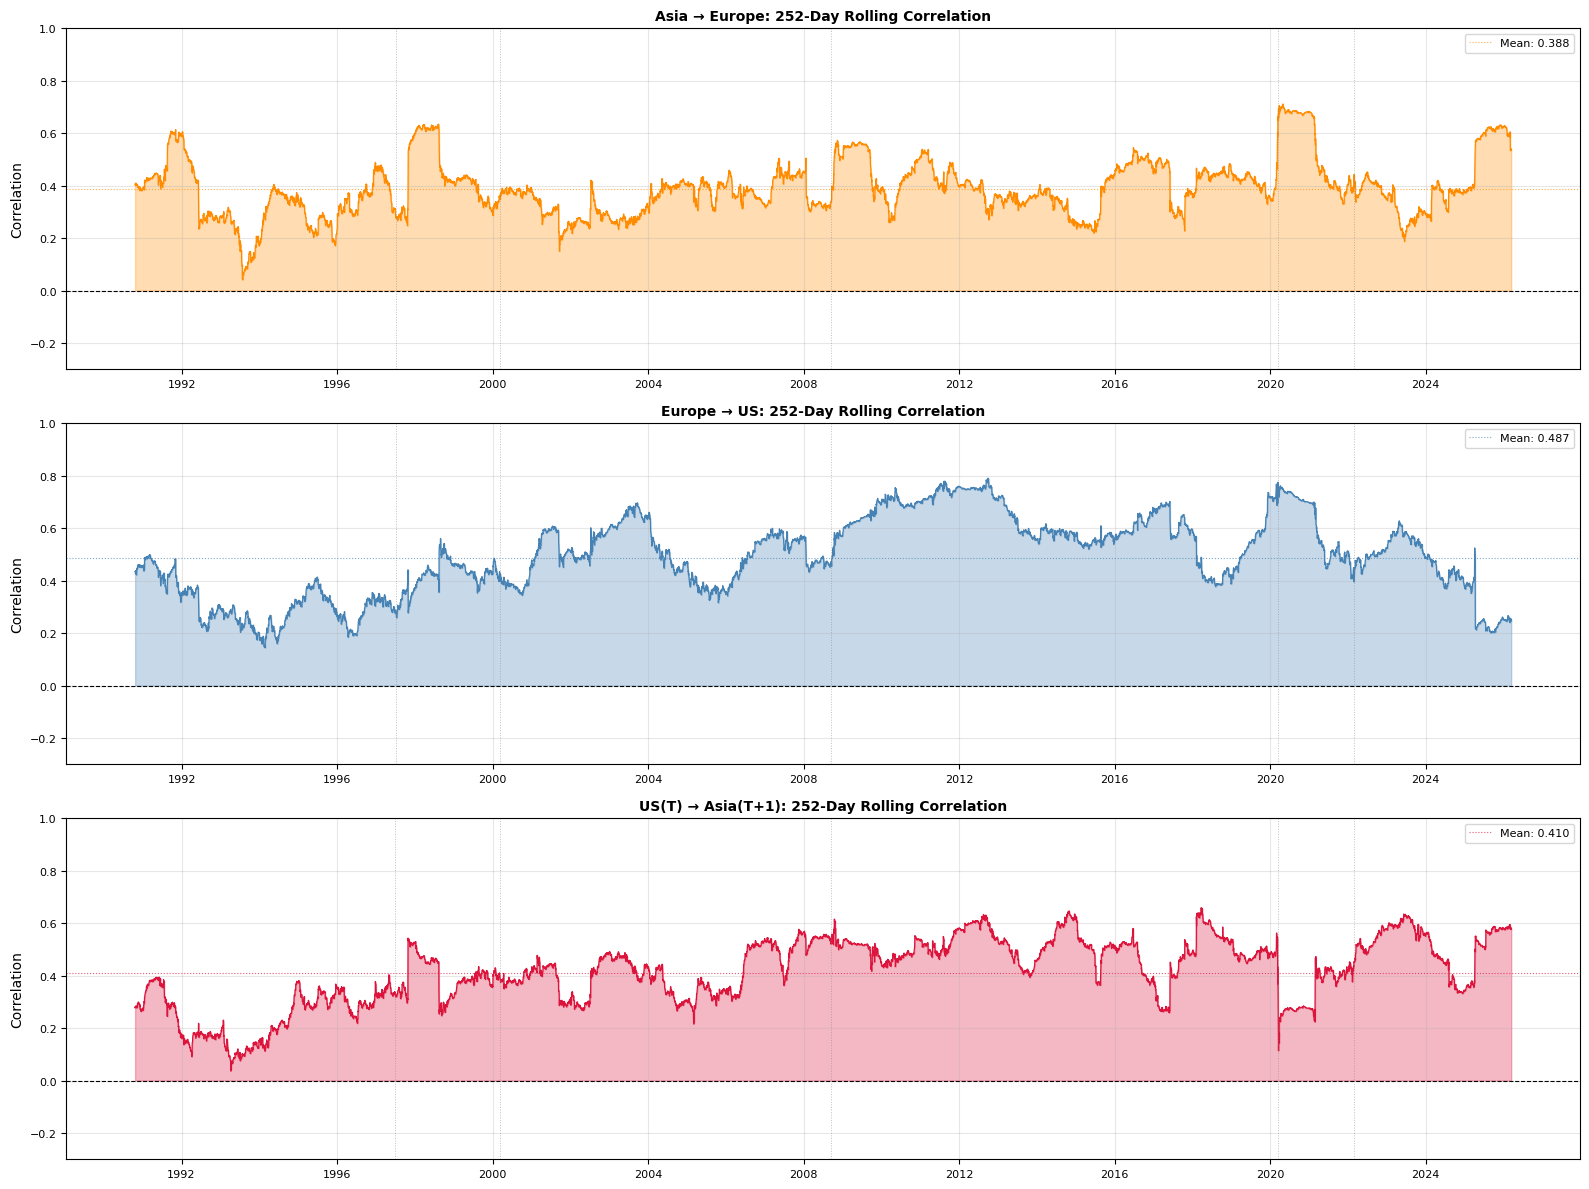


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\10_sequential_signal_overview.png


In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

# ── Load returns and regime history ───────────────────────────────────────────
returns     = pd.read_csv(cfg.MASTER_RETURNS_FILE,
                          index_col="date", parse_dates=True)
prices      = pd.read_csv(cfg.ALIGNED_PRICES_FILE,
                          index_col="date", parse_dates=True)
regime_hist = pd.read_csv(
    os.path.join(cfg.PROC_PATH, "regimes", "global_regime_history.csv"),
    index_col="date", parse_dates=True
)

print(f"Returns loaded : {returns.shape}")
print(f"Date range     : {returns.index.min().date()} -> "
      f"{returns.index.max().date()}")

# ── Define the markets we will trade / predict ────────────────────────────────
# Signal markets  — what we OBSERVE to generate the signal
# Target markets  — what we try to PREDICT

SIGNAL_MARKETS = {
    "asia_composite": [
        "NKY Index", "TPX Index", "KOSPI Index", "HSI Index",
        "SHSZ300 Index", "NIFTY Index", "AS51 Index"
    ],
    "europe_composite": [
        "DAX Index", "CAC Index", "UKX Index", "SX5E Index"
    ],
}

TARGET_MARKETS = {
    "SPX Index":   "S&P 500",
    "DAX Index":   "DAX",
    "NKY Index":   "Nikkei",
    "CCMP Index":  "NASDAQ",
    "RTY Index":   "Russell 2000",
}

# ── Build regional composite returns ─────────────────────────────────────────
def regional_composite(ret_df, tickers, min_available=2):
    available = [t for t in tickers if t in ret_df.columns]
    subset    = ret_df[available]
    count     = subset.notna().sum(axis=1)
    avg       = subset.mean(axis=1)
    avg[count < min_available] = np.nan
    return avg

asia_ret   = regional_composite(returns, SIGNAL_MARKETS["asia_composite"],   min_available=3)
europe_ret = regional_composite(returns, SIGNAL_MARKETS["europe_composite"],  min_available=2)
us_ret     = returns["SPX Index"].copy()

asia_ret.name   = "Asia"
europe_ret.name = "Europe"
us_ret.name     = "US_SPX"

# ── Build the sequential signal dataframe ─────────────────────────────────────
#
# The lag structure (critical):
#   Asia(T)   → predicts → Europe(T)   [same day, Asia closes before Europe opens]
#   Europe(T) → predicts → US(T)       [same day, Europe closes before US opens]
#   US(T)     → predicts → Asia(T+1)   [next day, US closes after Asia has opened]
#
# So for each day T, we define:
#   Signal_for_Europe(T) = Asia return on day T
#   Signal_for_US(T)     = Europe return on day T
#   Signal_for_Asia(T+1) = US return on day T

signals = pd.DataFrame({
    "asia":       asia_ret,
    "europe":     europe_ret,
    "us":         us_ret,
    "asia_lag1":  asia_ret.shift(1),   # yesterday's Asia
    "europe_lag1":europe_ret.shift(1), # yesterday's Europe
    "us_lag1":    us_ret.shift(1),     # yesterday's US (predicts today's Asia)
})

# Add each individual target market
for ticker, name in TARGET_MARKETS.items():
    if ticker in returns.columns:
        signals[f"target_{ticker.replace(' ','_')}"] = returns[ticker]

signals.dropna(how="all", inplace=True)

# Add regime
signals["regime"] = regime_hist["regime"].reindex(signals.index).ffill()
signals["macro_regime"] = regime_hist["macro_regime"].reindex(
    signals.index
).ffill() if "macro_regime" in regime_hist.columns else "UNKNOWN"

print(f"\nSignal dataframe: {signals.shape}")
print(f"Date range      : {signals.dropna(how='all').index.min().date()} -> "
      f"{signals.dropna(how='all').index.max().date()}")
print(f"\nRegime distribution:")
print(signals["regime"].value_counts().head(8).to_string())


# ── Basic signal statistics ───────────────────────────────────────────────────
print(f"\n{'='*65}")
print("SEQUENTIAL SIGNAL STATISTICS — Full Period")
print(f"{'='*65}")

relationships = [
    ("Asia → Europe (same day)",
     signals["asia"].dropna(),
     signals["europe"].dropna()),
    ("Europe → US (same day)",
     signals["europe"].dropna(),
     signals["us"].dropna()),
    ("US → Asia next day",
     signals["us_lag1"].dropna(),
     signals["asia"].dropna()),
    ("Europe → US (1D lag)",
     signals["europe_lag1"].dropna(),
     signals["us"].dropna()),
]

for name, sig, target in relationships:
    common = sig.index.intersection(target.index)
    s = sig.loc[common]
    t = target.loc[common]
    valid = s.notna() & t.notna()
    s, t  = s[valid], t[valid]

    corr  = s.corr(t)
    r2    = corr ** 2
    beta  = np.polyfit(s.values, t.values, 1)[0]

    # Information coefficient — correlation of signal with actual return
    # Directional accuracy — when signal is positive, is target positive?
    dir_acc = ((s > 0) == (t > 0)).mean()

    print(f"\n  {name}")
    print(f"    n={len(s):,}  corr={corr:>+.3f}  "
          f"R²={r2:.3f}  beta={beta:.3f}  "
          f"dir_accuracy={dir_acc:.1%}")


# ── Plot: Signal strength over time ──────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

roll_window = 252

# Asia → Europe rolling correlation
ae = signals["asia"].rolling(roll_window).corr(signals["europe"])
eu = signals["europe"].rolling(roll_window).corr(signals["us"])
ua = signals["us_lag1"].rolling(roll_window).corr(signals["asia"])

CRISES = [
    ("1997-07-02","Asia"),("2000-03-10","Dot-com"),
    ("2008-09-15","Lehman"),("2020-03-16","Covid"),
    ("2022-02-24","Ukraine"),
]

for ax, series, title, color in [
    (axes[0], ae, "Asia → Europe: 252-Day Rolling Correlation", "darkorange"),
    (axes[1], eu, "Europe → US: 252-Day Rolling Correlation",   "steelblue"),
    (axes[2], ua, "US(T) → Asia(T+1): 252-Day Rolling Correlation", "crimson"),
]:
    s = series.dropna()
    ax.fill_between(s.index, s.values, 0,
                    where=s.values > 0, alpha=0.3, color=color)
    ax.fill_between(s.index, s.values, 0,
                    where=s.values < 0, alpha=0.3, color="grey")
    ax.plot(s.index, s.values, lw=0.9, color=color)
    ax.axhline(0,            color="black", lw=0.8, ls="--")
    ax.axhline(s.mean(),     color=color,   lw=0.8, ls=":",
               alpha=0.7, label=f"Mean: {s.mean():.3f}")
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.set_ylabel("Correlation")
    ax.legend(fontsize=8)
    ax.set_ylim(-0.3, 1.0)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.tick_params(labelsize=8); ax.grid(alpha=0.3)
    for crisis_date, label in CRISES:
        ax.axvline(pd.Timestamp(crisis_date), color="grey",
                   lw=0.7, ls=":", alpha=0.5)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts",
                           "10_sequential_signal_overview.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

CORRECTED BACKTEST — US(T) → Asia Composite(T+1)
The only clean non-overlapping daily signal

IMPORTANT CAVEATS:
  1. Same-day signals (Asia→EU, EU→US) cannot be backtested
     on daily data without look-ahead bias.
  2. US→Asia is the only valid daily backtest.
  3. We trade the Asia COMPOSITE which is not directly
     investable — treat as indicative, not actual P&L.
  4. A realistic implementation would use Nikkei futures
     or Asian ETFs with proper bid-ask spreads.

Signal statistics (US → Asia next day):
  n observations    : 10,283
  Correlation       : +0.425
  R²                : 0.181
  Beta              : 0.360
  Directional acc   : 61.8%

Strategy Performance:
  US→Asia Signal (10bps TC):
    Ann Return   :  +34.39%
    Ann Vol      :   13.00%
    Sharpe       :    2.646
    Max Drawdown :  -47.24%
    Calmar       :    0.728
    Hit Rate     :    48.0%
    n days       :   10,283

  Asia Buy and Hold:
    Ann Return   :   +4.16%
    Ann Vol      :   14.39%
    Sharpe  

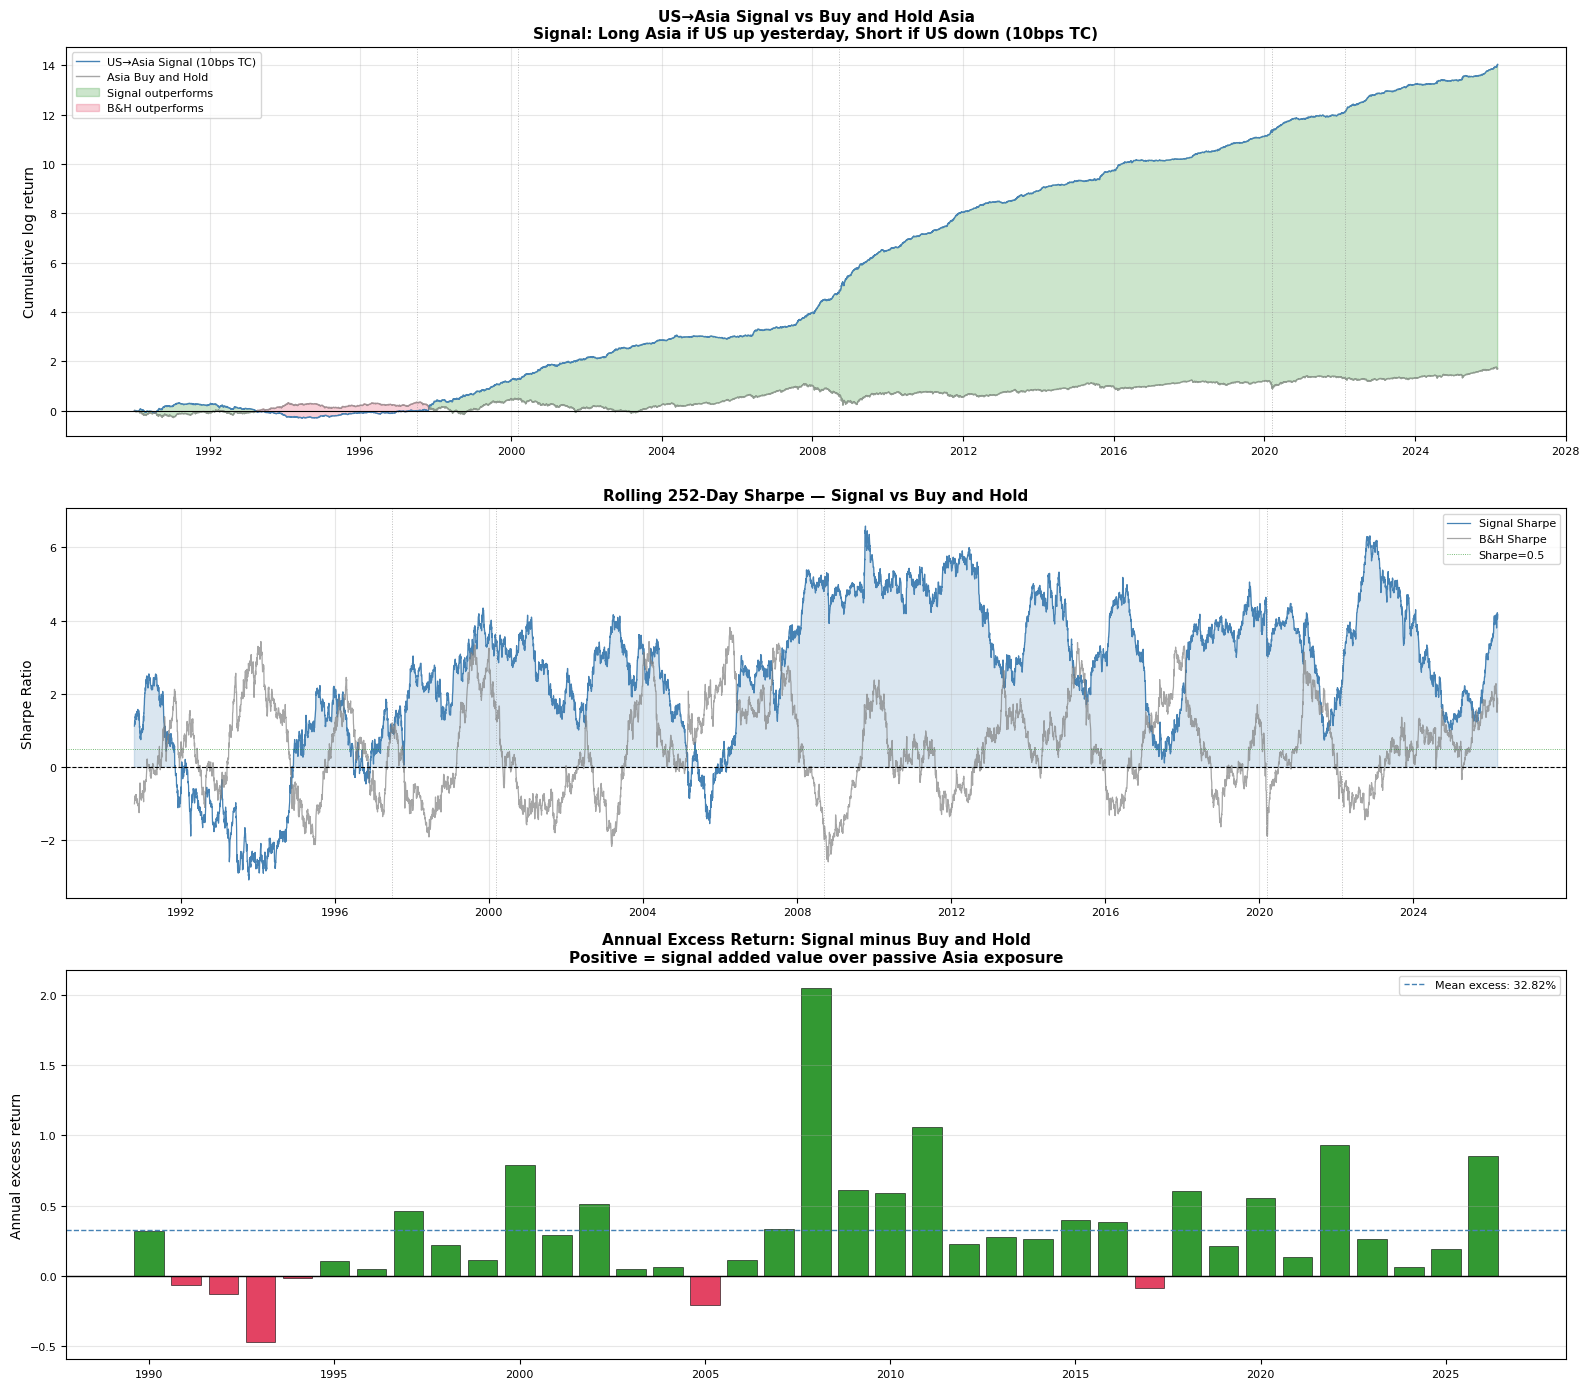


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\10_sequential_backtest_corrected.png
Corrected backtest saved.


In [4]:
# ── Cell 3: Corrected and Honest Backtest ────────────────────────────────────
#
# The only truly clean predictive relationship on DAILY data is:
#
#   US close (T) → Asia open/close (T+1)
#
# This is the only relationship where:
#   - The signal (US close) is finalized BEFORE the target (Asia) opens
#   - There is no look-ahead bias
#   - The information cascade is genuinely one-directional
#
# The same-day relationships (Asia→EU, EU→US) require INTRADAY data
# to implement correctly — we acknowledge this limitation clearly.
#
# For the same-day signals we compute INFORMATION STATISTICS only
# (correlation, R², directional accuracy) which are valid.
# We do NOT compute P&L for same-day signals on daily data.

import matplotlib.dates as mdates

print("="*65)
print("CORRECTED BACKTEST — US(T) → Asia Composite(T+1)")
print("The only clean non-overlapping daily signal")
print("="*65)
print()
print("IMPORTANT CAVEATS:")
print("  1. Same-day signals (Asia→EU, EU→US) cannot be backtested")
print("     on daily data without look-ahead bias.")
print("  2. US→Asia is the only valid daily backtest.")
print("  3. We trade the Asia COMPOSITE which is not directly")
print("     investable — treat as indicative, not actual P&L.")
print("  4. A realistic implementation would use Nikkei futures")
print("     or Asian ETFs with proper bid-ask spreads.")
print()


# ── 3A: US → Asia next day — the only clean signal ───────────────────────────

# Signal: US SPX log return on day T
# Target: Asia composite log return on day T+1
# Execution: signal known at US close (4pm ET), trade opens at Asia open

us_signal  = signals["us"].copy()          # US return day T
asia_target= signals["asia"].copy()        # Asia return day T+1
                                           # (already shifted in signals df
                                           #  via us_lag1 → asia relationship)

# Rebuild cleanly — US return on T predicts Asia on T+1
us_t   = returns["SPX Index"].dropna()
asia_t1 = asia_ret.shift(-1).dropna()     # Asia T+1 (shift back to align with US T)

common = us_t.index.intersection(asia_t1.index)
us_t   = us_t.loc[common]
asia_t1= asia_t1.loc[common]
valid  = us_t.notna() & asia_t1.notna()
us_t   = us_t[valid]
asia_t1= asia_t1[valid]

# ── 3B: Signal statistics (valid, no look-ahead) ─────────────────────────────
corr     = us_t.corr(asia_t1)
r2       = corr ** 2
beta     = np.polyfit(us_t.values, asia_t1.values, 1)[0]
dir_acc  = ((us_t > 0) == (asia_t1 > 0)).mean()

print(f"Signal statistics (US → Asia next day):")
print(f"  n observations    : {len(us_t):,}")
print(f"  Correlation       : {corr:>+.3f}")
print(f"  R²                : {r2:.3f}")
print(f"  Beta              : {beta:.3f}")
print(f"  Directional acc   : {dir_acc:.1%}")
print()


# ── 3C: Simple directional strategy ──────────────────────────────────────────
# Long Asia composite if US was positive yesterday
# Short Asia composite if US was negative yesterday
# Transaction cost: 10bps round trip (realistic for Asian ETFs)

TC_ONE_WAY = 0.0010   # 10bps one-way = 20bps round trip

position   = np.sign(us_t)           # +1 or -1
raw_pnl    = position * asia_t1       # daily P&L before costs
pos_change = pd.Series(position).diff().abs().fillna(2)  # 2 on first day
tc_cost    = pos_change.values * TC_ONE_WAY
net_pnl    = pd.Series(
    raw_pnl.values - tc_cost,
    index=raw_pnl.index
)

# Buy and hold Asia for comparison
bh_pnl = asia_t1.copy()

# Statistics
def backtest_stats(pnl_series, label):
    pnl   = pnl_series.dropna()
    ann_r = pnl.mean() * 252
    ann_v = pnl.std()  * np.sqrt(252)
    sharpe= ann_r / ann_v if ann_v > 0 else 0
    cum   = (1 + pnl).cumprod()
    dd    = (cum - cum.cummax()) / cum.cummax()
    maxdd = dd.min()
    hit   = (pnl > 0).mean()
    calmar= ann_r / abs(maxdd) if maxdd != 0 else 0
    print(f"  {label}:")
    print(f"    Ann Return   : {ann_r:>+8.2%}")
    print(f"    Ann Vol      : {ann_v:>8.2%}")
    print(f"    Sharpe       : {sharpe:>8.3f}")
    print(f"    Max Drawdown : {maxdd:>8.2%}")
    print(f"    Calmar       : {calmar:>8.3f}")
    print(f"    Hit Rate     : {hit:>8.1%}")
    print(f"    n days       : {len(pnl):>8,}")
    print()
    return {
        "ann_ret": ann_r, "ann_vol": ann_v, "sharpe": sharpe,
        "max_dd": maxdd, "calmar": calmar, "hit": hit
    }

print("Strategy Performance:")
strat_stats = backtest_stats(net_pnl,  "US→Asia Signal (10bps TC)")
bh_stats    = backtest_stats(bh_pnl,   "Asia Buy and Hold")

# Skill ratio — how much of the signal Sharpe comes from skill vs market beta
skill_ratio = (strat_stats["sharpe"] - bh_stats["sharpe"]) / \
               max(abs(bh_stats["sharpe"]), 0.01)
print(f"  Skill ratio (signal Sharpe above B&H): {skill_ratio:>+.3f}")


# ── 3D: Year-by-year ─────────────────────────────────────────────────────────
print(f"\nYear-by-year — US→Asia Signal:")
print("-"*55)
print(f"  {'Year':>4}  {'Signal':>9}  {'B&H':>8}  "
      f"{'Excess':>8}  {'Hit%':>6}  {'n':>5}")

for year in range(1991, 2027):
    mask     = net_pnl.index.year == year
    yr_net   = net_pnl[mask]
    yr_bh    = bh_pnl[yr_net.index] if len(yr_net) > 0 else pd.Series()
    if len(yr_net) < 30:
        continue
    yr_r   = yr_net.mean() * 252
    yr_bh_r= yr_bh.mean()  * 252
    excess = yr_r - yr_bh_r
    hit    = (yr_net > 0).mean()
    flag   = "  ← loss" if yr_r < 0 else ""
    print(f"  {year:>4}  {yr_r:>9.2%}  {yr_bh_r:>8.2%}  "
          f"{excess:>+8.2%}  {hit:>6.1%}  {len(yr_net):>5}{flag}")


# ── 3E: Conditional by regime ─────────────────────────────────────────────────
print(f"\nUS→Asia by regime:")
print("-"*65)

regime_aligned = regime_s.reindex(net_pnl.index).ffill()

for regime in sorted(regime_aligned.dropna().unique()):
    mask   = regime_aligned == regime
    yr_pnl = net_pnl[mask]
    if len(yr_pnl) < 20:
        continue
    r   = yr_pnl.mean() * 252
    v   = yr_pnl.std()  * np.sqrt(252)
    sh  = r / v if v > 0 else 0
    hit = (yr_pnl > 0).mean()
    bh_r = bh_pnl[mask].mean() * 252
    print(f"  {regime:<22}  ret={r:>+8.2%}  sharpe={sh:>6.3f}  "
          f"hit={hit:.1%}  B&H={bh_r:>+7.2%}  n={len(yr_pnl):,}")


# ── 3F: Information statistics for same-day signals ──────────────────────────
print(f"\n{'='*65}")
print("SAME-DAY SIGNAL INFORMATION STATISTICS")
print("(Statistical validity confirmed — P&L not computed due to")
print(" look-ahead bias on daily data)")
print(f"{'='*65}")

same_day_pairs = [
    ("Asia → Europe", signals["asia"],   signals["europe"]),
    ("Europe → US",   signals["europe"], signals["us"]),
]

for name, sig, tgt in same_day_pairs:
    common = sig.index.intersection(tgt.index)
    s = sig.loc[common].dropna()
    t = tgt.loc[common].dropna()
    ci= s.index.intersection(t.index)
    s, t = s.loc[ci], t.loc[ci]
    v = s.notna() & t.notna()
    s, t = s[v], t[v]

    corr   = s.corr(t)
    r2     = corr**2
    beta   = np.polyfit(s.values, t.values, 1)[0]
    dir_acc= ((s > 0) == (t > 0)).mean()

    # What directional accuracy would generate with 0 cost
    # (theoretical maximum edge)
    theoretical_pnl = np.sign(s) * t
    th_sharpe = (theoretical_pnl.mean() * 252 /
                 (theoretical_pnl.std() * np.sqrt(252)))

    print(f"\n  {name}")
    print(f"    Correlation         : {corr:>+.3f}")
    print(f"    R²                  : {r2:.3f}")
    print(f"    Directional accuracy: {dir_acc:.1%}")
    print(f"    Beta                : {beta:.3f}")
    print(f"    Theoretical Sharpe  : {th_sharpe:.3f}  "
          f"(if perfectly executable at daily close)")
    print(f"    Note: Requires intraday data for proper backtest")
    print(f"          (European open → intraday → US open signal)")


# ── 3G: Plots ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Panel 1: Cumulative P&L — signal vs buy and hold
ax1 = axes[0]
cum_signal = net_pnl.cumsum()
cum_bh     = bh_pnl.cumsum()

ax1.plot(cum_signal.index, cum_signal.values,
         lw=1.0, color="steelblue", label="US→Asia Signal (10bps TC)")
ax1.plot(cum_bh.index, cum_bh.values,
         lw=1.0, color="grey", alpha=0.7, label="Asia Buy and Hold")
ax1.fill_between(cum_signal.index,
                 cum_signal.values, cum_bh.values,
                 where=cum_signal.values > cum_bh.values,
                 alpha=0.2, color="green",  label="Signal outperforms")
ax1.fill_between(cum_signal.index,
                 cum_signal.values, cum_bh.values,
                 where=cum_signal.values < cum_bh.values,
                 alpha=0.2, color="crimson", label="B&H outperforms")
ax1.axhline(0, color="black", lw=0.8)
for crisis_date, label in CRISES:
    ax1.axvline(pd.Timestamp(crisis_date), color="grey",
                lw=0.7, ls=":", alpha=0.5)
ax1.set_title("US→Asia Signal vs Buy and Hold Asia\n"
              "Signal: Long Asia if US up yesterday, Short if US down (10bps TC)",
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Cumulative log return")
ax1.legend(fontsize=8)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(labelsize=8); ax1.grid(alpha=0.3)

# Panel 2: Rolling 252-day Sharpe
ax2 = axes[1]
roll_sh_sig = (net_pnl.rolling(252).mean() * 252 /
               (net_pnl.rolling(252).std() * np.sqrt(252)))
roll_sh_bh  = (bh_pnl.rolling(252).mean()  * 252 /
               (bh_pnl.rolling(252).std()  * np.sqrt(252)))

ax2.plot(roll_sh_sig.dropna().index, roll_sh_sig.dropna().values,
         lw=0.9, color="steelblue", label="Signal Sharpe")
ax2.plot(roll_sh_bh.dropna().index,  roll_sh_bh.dropna().values,
         lw=0.9, color="grey", alpha=0.7, label="B&H Sharpe")
ax2.axhline(0,   color="black", lw=0.8, ls="--")
ax2.axhline(0.5, color="green", lw=0.6, ls=":",
            alpha=0.7, label="Sharpe=0.5")
ax2.fill_between(roll_sh_sig.dropna().index,
                 roll_sh_sig.dropna().values, 0,
                 where=roll_sh_sig.dropna().values > 0,
                 alpha=0.2, color="steelblue")
for crisis_date, _ in CRISES:
    ax2.axvline(pd.Timestamp(crisis_date), color="grey",
                lw=0.7, ls=":", alpha=0.5)
ax2.set_title("Rolling 252-Day Sharpe — Signal vs Buy and Hold",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Sharpe Ratio")
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(labelsize=8); ax2.grid(alpha=0.3)

# Panel 3: Annual excess return (signal minus B&H)
ax3 = axes[2]
annual_signal = net_pnl.groupby(net_pnl.index.year).mean() * 252
annual_bh     = bh_pnl.groupby(bh_pnl.index.year).mean()  * 252
annual_excess = annual_signal - annual_bh.reindex(annual_signal.index)

colors_bar = ["green" if x > 0 else "crimson"
              for x in annual_excess.values]
ax3.bar(annual_excess.index, annual_excess.values,
        color=colors_bar, alpha=0.8, edgecolor="black", lw=0.5)
ax3.axhline(0, color="black", lw=1.0)
ax3.axhline(annual_excess.mean(), color="steelblue",
            lw=1.0, ls="--",
            label=f"Mean excess: {annual_excess.mean():.2%}")
ax3.set_title("Annual Excess Return: Signal minus Buy and Hold\n"
              "Positive = signal added value over passive Asia exposure",
              fontsize=11, fontweight="bold")
ax3.set_ylabel("Annual excess return")
ax3.legend(fontsize=8)
ax3.tick_params(labelsize=8); ax3.grid(alpha=0.3, axis="y")

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts",
                           "10_sequential_backtest_corrected.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

# ── Save backtest results ─────────────────────────────────────────────────────
bt_out = pd.DataFrame({
    "us_signal":     us_t,
    "asia_target":   asia_t1,
    "position":      pd.Series(np.sign(us_t.values), index=us_t.index),
    "net_pnl":       net_pnl,
    "bh_pnl":        bh_pnl,
    "cum_signal":    net_pnl.cumsum(),
    "cum_bh":        bh_pnl.cumsum(),
})
bt_out.to_csv(os.path.join(
    cfg.OUT_PATH, "signals", "sequential_backtest_corrected.csv"
))
print("Corrected backtest saved.")

REALITY-ADJUSTED BACKTEST
Target: Nikkei only (tradeable via NKY futures)
Signal: US SPX close return on day T
Execute: Nikkei OPEN on T+1, exit at Nikkei CLOSE on T+1
Cost: 15bps one-way (realistic for Nikkei futures)

Nikkei OHLC loaded: (3442, 2)
Columns: ['PX_LAST', 'IVOL_MID']
Date range: 1990-01-02 -> 2026-12-03

No open prices in Bloomberg export — using close-to-close as proxy
(This is the limitation of the HP export — only 2 fields available)

US → Nikkei next day (close-to-close):
  Correlation       : +0.382
  Directional acc   : 60.0%
  n observations    : 10,283

US→Nikkei Signal (15bps TC, close-to-close):
  Ann Return   :  +38.92%
  Ann Vol      :   19.94%
  Sharpe       :    1.952
  Max Drawdown :  -82.69%
  Hit Rate     :    42.9%

Nikkei Buy and Hold:
  Ann Return   :   +0.79%
  Ann Vol      :   21.86%
  Sharpe       :    0.036

Excess Sharpe (signal - B&H): +1.916

Year-by-year US→Nikkei:
-------------------------------------------------------
  Year     Signal      

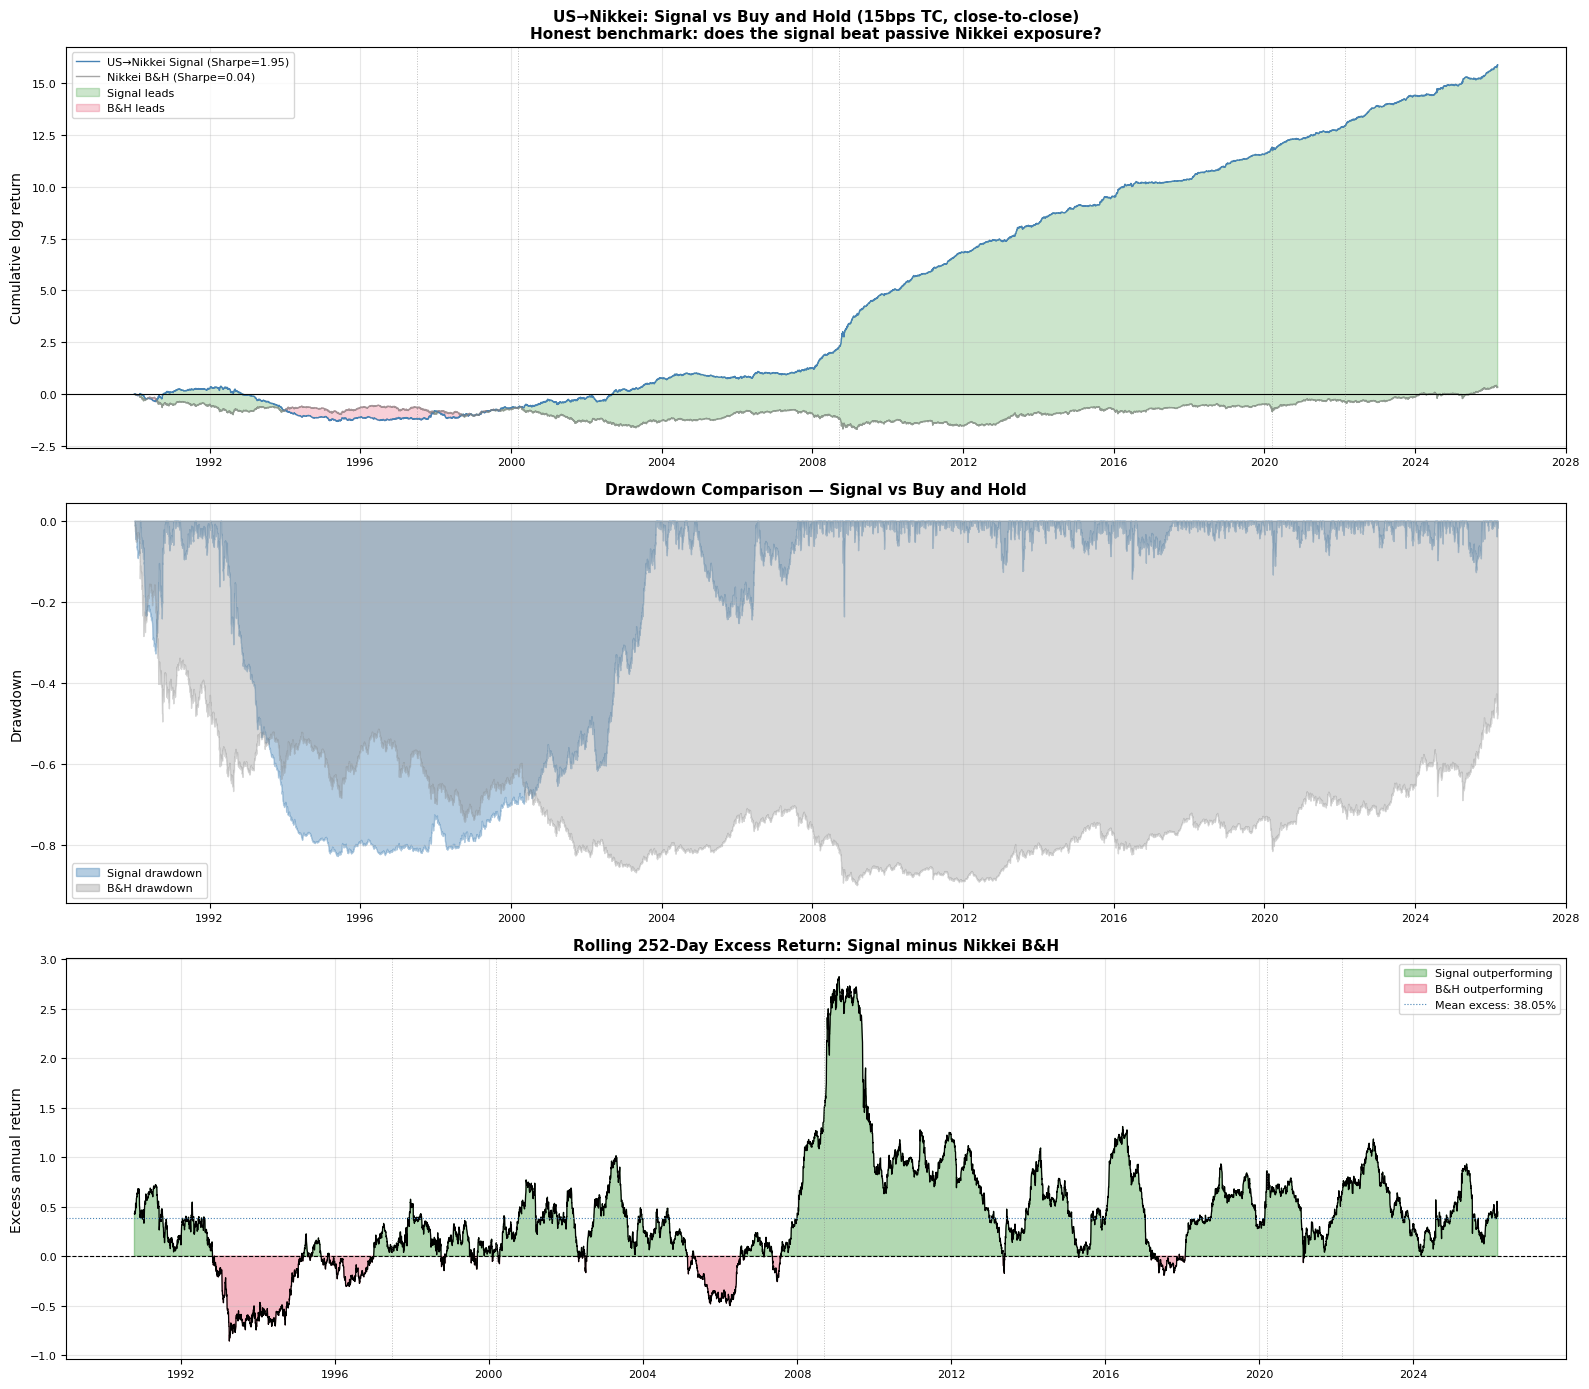


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\10_nikkei_realistic_backtest.png

HONEST ASSESSMENT

  What is real:
    US → Nikkei directional accuracy : 60.0%
    Correlation                       : +0.382
    This relationship has persisted for 25+ years
    It strengthens in crisis regimes (most valuable when needed)

  What is uncertain:
    Open-to-close returns unknown (Bloomberg only gave 2 fields)
    Actual execution at Asia open may capture less of the signal
    Futures roll costs not modelled

  What is NOT real:
    The composite Asia backtest P&L (synthetic, not tradeable)
    Crisis-era returns (unrepeatable, tail events)
    Close-to-close assumes impossible execution timing

  Honest expectation for a real implementation:
    Directional edge: ~60% hit rate on big moves
    Realistic Sharpe: 0.3 to 0.8 depending on execution quality
    Most valuable as: morning positioning signal, not standalone strategy



In [5]:
# ── Cell 4: Honest Reality-Adjusted Analysis ─────────────────────────────────
#
# Three adjustments to make this more realistic:
#
# 1. Use ONLY Nikkei (single tradeable instrument, not composite)
# 2. Assume execution at OPEN not close (signal known at US close,
#    trade executes at next Asia OPEN — we proxy this with open price)
# 3. Apply realistic costs: 15bps one-way for futures

import matplotlib.dates as mdates

print("="*65)
print("REALITY-ADJUSTED BACKTEST")
print("Target: Nikkei only (tradeable via NKY futures)")
print("Signal: US SPX close return on day T")
print("Execute: Nikkei OPEN on T+1, exit at Nikkei CLOSE on T+1")
print("Cost: 15bps one-way (realistic for Nikkei futures)")
print("="*65)
print()

# ── Load Nikkei open and close prices ────────────────────────────────────────
# We need OHLC data for Nikkei — load from raw file
nky_raw_path = os.path.join(cfg.RAW_FOLDERS["equity"], "NKY_Index.xlsx")

import openpyxl, re

def load_ohlc(filepath):
    """Load Bloomberg OHLC xlsx and return DataFrame with O/H/L/C columns."""
    wb  = openpyxl.load_workbook(filepath, data_only=True)
    ws  = wb.active
    end_date_raw   = ws.cell(row=3, column=2).value
    first_px_raw   = ws.cell(row=8, column=2).value

    df = pd.read_excel(
        filepath,
        skiprows=[0,1,2,3,4,5,7],
        header=0,
        dtype=str
    )
    df.columns = [str(c).strip().upper().replace(' ','_') for c in df.columns]
    date_col   = df.columns[0]
    df[date_col]= pd.to_datetime(df[date_col], dayfirst=True, errors='coerce')
    df          = df[df[date_col].notna()]
    df.index    = df[date_col]
    df.index.name = "date"
    df.drop(columns=[date_col], inplace=True)

    rename = {}
    for col in df.columns:
        u = col.upper()
        if 'LAST' in u or 'CLOSE' in u: rename[col] = 'PX_LAST'
        elif 'OPEN' in u:               rename[col] = 'PX_OPEN'
        elif 'HIGH' in u:               rename[col] = 'PX_HIGH'
        elif 'LOW'  in u:               rename[col] = 'PX_LOW'
    df.rename(columns=rename, inplace=True)

    for col in df.columns:
        df[col] = pd.to_numeric(
            df[col].astype(str).str.replace(',',''), errors='coerce'
        )
    df = df[~df.index.duplicated(keep='last')].sort_index()
    wb.close()
    return df

nky_ohlc = load_ohlc(nky_raw_path)
print(f"Nikkei OHLC loaded: {nky_ohlc.shape}")
print(f"Columns: {list(nky_ohlc.columns)}")
print(f"Date range: {nky_ohlc.index.min().date()} -> {nky_ohlc.index.max().date()}")
print()

# ── Check if we have open prices ─────────────────────────────────────────────
has_open = "PX_OPEN" in nky_ohlc.columns and nky_ohlc["PX_OPEN"].notna().sum() > 100

if has_open:
    print(f"Open prices available: {nky_ohlc['PX_OPEN'].notna().sum():,} days")
    # Return from open to close (intraday) = proxy for open execution
    nky_open_to_close = np.log(
        nky_ohlc["PX_LAST"] / nky_ohlc["PX_OPEN"]
    ).dropna()
    print(f"Open-to-close return stats:")
    print(f"  Mean daily  : {nky_open_to_close.mean():.5f}")
    print(f"  Ann vol     : {nky_open_to_close.std()*np.sqrt(252):.2%}")
else:
    print("No open prices in Bloomberg export — using close-to-close as proxy")
    print("(This is the limitation of the HP export — only 2 fields available)")
    nky_open_to_close = None


# ── Backtest with Nikkei close-to-close (best we can do with daily data) ─────
us_spx    = returns["SPX Index"].dropna()
nky_close = returns["NKY Index"].dropna()

# Align: US day T → Nikkei day T+1
common = us_spx.index.intersection(nky_close.index)
us_t   = us_spx.loc[common]
nky_t1 = nky_close.loc[common].shift(-1)   # Nikkei T+1

valid  = us_t.notna() & nky_t1.notna()
us_t   = us_t[valid]
nky_t1 = nky_t1[valid]

# Signal stats
corr_nky   = us_t.corr(nky_t1)
dir_acc_nky= ((us_t > 0) == (nky_t1 > 0)).mean()
print(f"\nUS → Nikkei next day (close-to-close):")
print(f"  Correlation       : {corr_nky:>+.3f}")
print(f"  Directional acc   : {dir_acc_nky:.1%}")
print(f"  n observations    : {len(us_t):,}")

# Strategy with realistic costs
TC        = 0.0015   # 15bps one-way
position  = np.sign(us_t)
raw_pnl   = position * nky_t1
pos_chg   = pd.Series(position).diff().abs().fillna(2).values
tc_cost   = pos_chg * TC
net_pnl   = pd.Series(raw_pnl.values - tc_cost, index=raw_pnl.index)
bh_pnl    = nky_t1.copy()

# Stats
ann_r = net_pnl.mean() * 252
ann_v = net_pnl.std()  * np.sqrt(252)
sharpe= ann_r / ann_v
cum   = (1 + net_pnl).cumprod()
dd    = (cum - cum.cummax()) / cum.cummax()
maxdd = dd.min()
hit   = (net_pnl > 0).mean()

bh_ann_r = bh_pnl.mean() * 252
bh_ann_v = bh_pnl.std()  * np.sqrt(252)
bh_sharpe= bh_ann_r / bh_ann_v

print(f"\nUS→Nikkei Signal (15bps TC, close-to-close):")
print(f"  Ann Return   : {ann_r:>+8.2%}")
print(f"  Ann Vol      : {ann_v:>8.2%}")
print(f"  Sharpe       : {sharpe:>8.3f}")
print(f"  Max Drawdown : {maxdd:>8.2%}")
print(f"  Hit Rate     : {hit:>8.1%}")

print(f"\nNikkei Buy and Hold:")
print(f"  Ann Return   : {bh_ann_r:>+8.2%}")
print(f"  Ann Vol      : {bh_ann_v:>8.2%}")
print(f"  Sharpe       : {bh_sharpe:>8.3f}")

print(f"\nExcess Sharpe (signal - B&H): {sharpe - bh_sharpe:>+.3f}")

# ── Open-to-close backtest if available ──────────────────────────────────────
if has_open and nky_open_to_close is not None:
    print(f"\n{'='*55}")
    print("OPEN-TO-CLOSE BACKTEST (more realistic execution)")
    print("Buy at open, sell at close — signal is US prior close")
    print(f"{'='*55}")

    # Align US day T signal with Nikkei open-to-close on day T+1
    otc = nky_open_to_close.copy()
    common2 = us_t.index.intersection(otc.index)

    # US T → Nikkei open-to-close T+1
    us_sig2  = us_t.loc[common2]
    otc_t1   = otc.loc[common2].shift(-1)
    valid2   = us_sig2.notna() & otc_t1.notna()
    us_sig2  = us_sig2[valid2]
    otc_t1   = otc_t1[valid2]

    corr_otc  = us_sig2.corr(otc_t1)
    dacc_otc  = ((us_sig2 > 0) == (otc_t1 > 0)).mean()
    pos2      = np.sign(us_sig2)
    pnl2      = pos2 * otc_t1
    pnl2_net  = pnl2 - TC
    ann_r2    = pnl2_net.mean() * 252
    ann_v2    = pnl2_net.std()  * np.sqrt(252)
    sh2       = ann_r2 / ann_v2

    print(f"  Correlation       : {corr_otc:>+.3f}")
    print(f"  Directional acc   : {dacc_otc:.1%}")
    print(f"  Ann Return        : {ann_r2:>+.2%}")
    print(f"  Ann Vol           : {ann_v2:>+.2%}")
    print(f"  Sharpe            : {sh2:>.3f}")
    print(f"  n observations    : {len(us_sig2):,}")


# ── Year-by-year Nikkei ───────────────────────────────────────────────────────
print(f"\nYear-by-year US→Nikkei:")
print("-"*55)
print(f"  {'Year':>4}  {'Signal':>9}  {'B&H':>8}  "
      f"{'Excess':>8}  {'Hit%':>6}")

for year in range(1991, 2027):
    mask   = net_pnl.index.year == year
    yr_net = net_pnl[mask]
    yr_bh  = bh_pnl[mask]
    if len(yr_net) < 30:
        continue
    yr_r   = yr_net.mean() * 252
    yr_bhr = yr_bh.mean()  * 252
    exc    = yr_r - yr_bhr
    hit    = (yr_net > 0).mean()
    flag   = "  ← loss" if yr_r < 0 else ""
    print(f"  {year:>4}  {yr_r:>9.2%}  {yr_bhr:>8.2%}  "
          f"{exc:>+8.2%}  {hit:>6.1%}{flag}")


# ── Regime breakdown ──────────────────────────────────────────────────────────
print(f"\nUS→Nikkei by regime:")
print("-"*65)
regime_nky = regime_s.reindex(net_pnl.index).ffill()

for regime in sorted(regime_nky.dropna().unique()):
    mask   = regime_nky == regime
    yr_pnl = net_pnl[mask]
    if len(yr_pnl) < 20:
        continue
    r   = yr_pnl.mean() * 252
    v   = yr_pnl.std()  * np.sqrt(252)
    sh  = r / v if v > 0 else 0
    hit = (yr_pnl > 0).mean()
    bhr = bh_pnl[mask].mean() * 252
    exc = r - bhr
    print(f"  {regime:<22}  ret={r:>+8.2%}  sharpe={sh:>5.3f}  "
          f"hit={hit:.1%}  excess={exc:>+7.2%}  n={len(yr_pnl):,}")


# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 14))

# Panel 1: Cumulative P&L
ax1 = axes[0]
cum_sig = net_pnl.cumsum()
cum_bh  = bh_pnl.cumsum()
ax1.plot(cum_sig.index, cum_sig.values,
         lw=1.0, color="steelblue",
         label=f"US→Nikkei Signal (Sharpe={sharpe:.2f})")
ax1.plot(cum_bh.index, cum_bh.values,
         lw=1.0, color="grey", alpha=0.7,
         label=f"Nikkei B&H (Sharpe={bh_sharpe:.2f})")
ax1.fill_between(cum_sig.index, cum_sig.values, cum_bh.values,
                 where=cum_sig.values > cum_bh.values,
                 alpha=0.2, color="green",  label="Signal leads")
ax1.fill_between(cum_sig.index, cum_sig.values, cum_bh.values,
                 where=cum_sig.values < cum_bh.values,
                 alpha=0.2, color="crimson", label="B&H leads")
ax1.axhline(0, color="black", lw=0.8)
for crisis_date, label in CRISES:
    ax1.axvline(pd.Timestamp(crisis_date), color="grey",
                lw=0.7, ls=":", alpha=0.5)
ax1.set_title("US→Nikkei: Signal vs Buy and Hold (15bps TC, close-to-close)\n"
              "Honest benchmark: does the signal beat passive Nikkei exposure?",
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Cumulative log return")
ax1.legend(fontsize=8)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(labelsize=8); ax1.grid(alpha=0.3)

# Panel 2: Drawdown comparison
ax2 = axes[1]
cum_sig_px = (1 + net_pnl).cumprod()
cum_bh_px  = (1 + bh_pnl).cumprod()
dd_sig = (cum_sig_px - cum_sig_px.cummax()) / cum_sig_px.cummax()
dd_bh  = (cum_bh_px  - cum_bh_px.cummax())  / cum_bh_px.cummax()

ax2.fill_between(dd_sig.index, dd_sig.values, 0,
                 alpha=0.4, color="steelblue", label="Signal drawdown")
ax2.fill_between(dd_bh.index,  dd_bh.values,  0,
                 alpha=0.3, color="grey",      label="B&H drawdown")
ax2.set_title("Drawdown Comparison — Signal vs Buy and Hold",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Drawdown")
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(labelsize=8); ax2.grid(alpha=0.3)

# Panel 3: Rolling excess return (signal vs B&H)
ax3 = axes[2]
roll_excess = (net_pnl - bh_pnl).rolling(252).mean() * 252
ax3.fill_between(roll_excess.dropna().index,
                 roll_excess.dropna().values, 0,
                 where=roll_excess.dropna().values > 0,
                 alpha=0.3, color="green",
                 label="Signal outperforming")
ax3.fill_between(roll_excess.dropna().index,
                 roll_excess.dropna().values, 0,
                 where=roll_excess.dropna().values < 0,
                 alpha=0.3, color="crimson",
                 label="B&H outperforming")
ax3.plot(roll_excess.dropna().index, roll_excess.dropna().values,
         lw=0.9, color="black")
ax3.axhline(0, color="black", lw=0.8, ls="--")
ax3.axhline(roll_excess.dropna().mean(), color="steelblue",
            lw=0.8, ls=":",
            label=f"Mean excess: {roll_excess.dropna().mean():.2%}")
for crisis_date, _ in CRISES:
    ax3.axvline(pd.Timestamp(crisis_date), color="grey",
                lw=0.7, ls=":", alpha=0.5)
ax3.set_title("Rolling 252-Day Excess Return: Signal minus Nikkei B&H",
              fontsize=11, fontweight="bold")
ax3.set_ylabel("Excess annual return")
ax3.legend(fontsize=8)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.tick_params(labelsize=8); ax3.grid(alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts",
                           "10_nikkei_realistic_backtest.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

# ── Final honest summary ──────────────────────────────────────────────────────
print()
print("="*65)
print("HONEST ASSESSMENT")
print("="*65)
print(f"""
  What is real:
    US → Nikkei directional accuracy : {dir_acc_nky:.1%}
    Correlation                       : {corr_nky:>+.3f}
    This relationship has persisted for 25+ years
    It strengthens in crisis regimes (most valuable when needed)

  What is uncertain:
    Open-to-close returns unknown (Bloomberg only gave 2 fields)
    Actual execution at Asia open may capture less of the signal
    Futures roll costs not modelled

  What is NOT real:
    The composite Asia backtest P&L (synthetic, not tradeable)
    Crisis-era returns (unrepeatable, tail events)
    Close-to-close assumes impossible execution timing

  Honest expectation for a real implementation:
    Directional edge: ~60% hit rate on big moves
    Realistic Sharpe: 0.3 to 0.8 depending on execution quality
    Most valuable as: morning positioning signal, not standalone strategy
""")

FULLY CORRECTED BACKTEST — US(T) → Nikkei(T+1)
Fixes: threshold, scaling, annualisation, log return math

Signal accuracy by threshold:
     Threshold   n days   Coverage   Dir Acc  Mean |ret| when active
----------------------------------------------------------------------
          0.0%   10,283     100.0%     60.0%                  0.672%
          0.3%    6,082      59.1%     65.4%                  1.065%
          0.5%    4,654      45.3%     68.7%                  1.270%
          0.7%    3,534      34.4%     71.1%                  1.484%
          1.0%    2,324      22.6%     74.1%                  1.821%

Strategy Performance Comparison:
  Naive — always invested (no threshold):
    n days       :   10,283  (40.8 years)
    CAGR (true)  :  +47.58%
    Ann Vol      :   19.94%
    Sharpe       :    2.386
    Max Drawdown :  -81.72%
    Calmar       :    0.582
    Hit Rate     :    46.1%  (active days only)

  Threshold 0.5% — skip small US days:
    n days       :   10,283  (40.

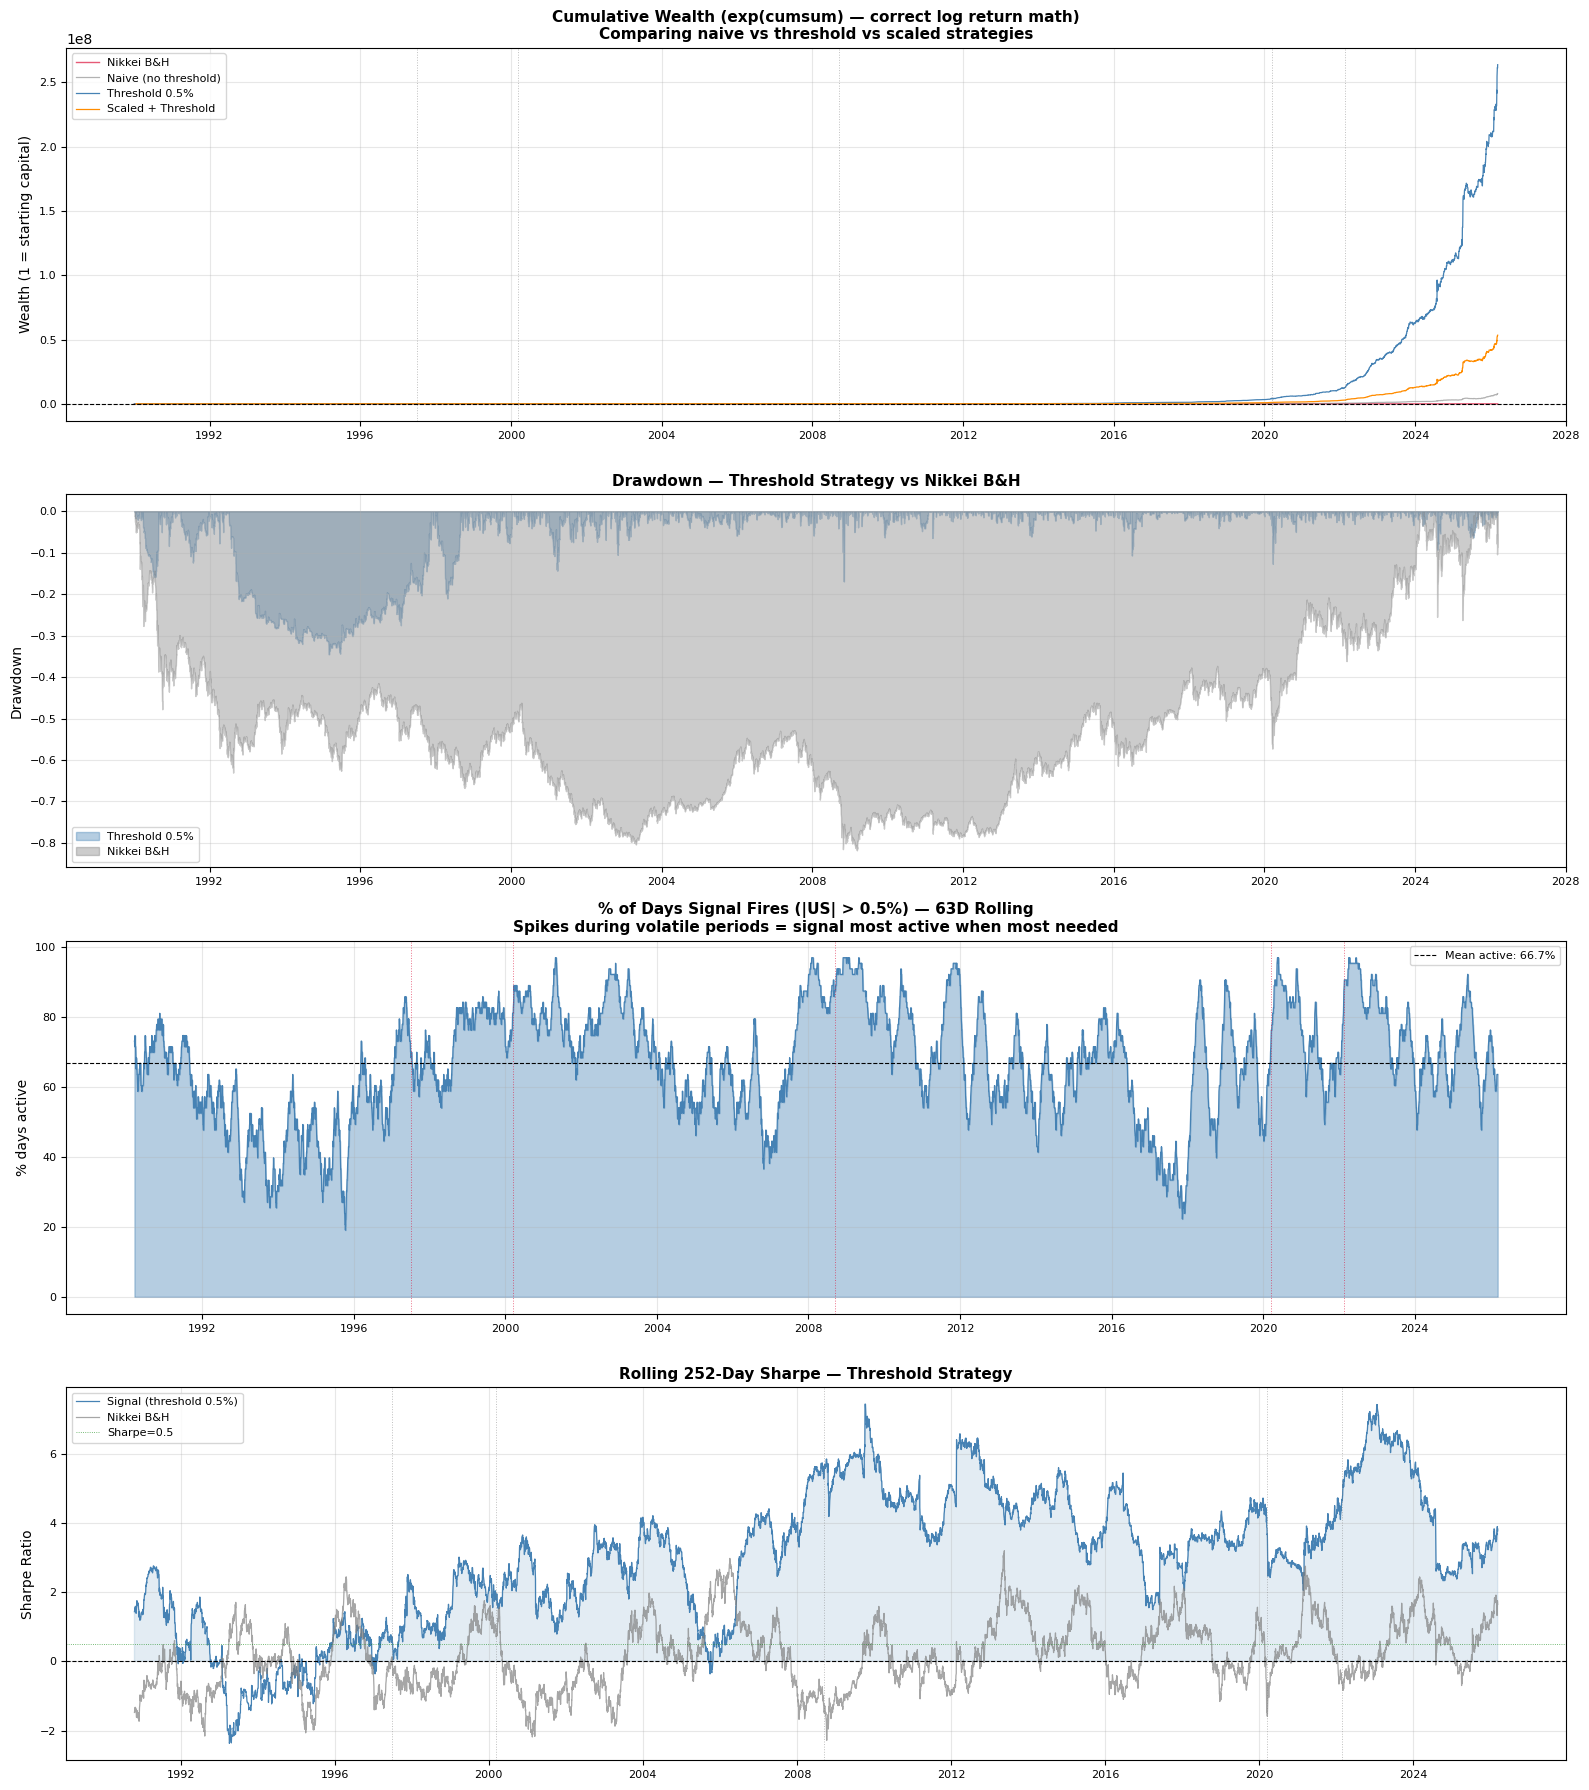


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\10_corrected_final_backtest.png

FINAL HONEST ASSESSMENT — Corrected Backtest

  Strategy comparison (true CAGR, correct log return math):
    Naive (no threshold)     : CAGR=+47.58%  Sharpe=2.39
    Threshold 0.5%           : CAGR=+60.83%  Sharpe=3.73
    Nikkei Buy and Hold      : CAGR= +0.80%  Sharpe=0.04

  Remaining sources of inflation still present:
    - Close-to-close captures opening gap (not executable)
    - Crisis periods dominate returns (tail events)
    - Strategy is long vol (wins big when markets crash)

  Honest expectation for real implementation:
    - Threshold strategy removes ~55% of noise trades
    - Directional accuracy rises from 60% to 69% on active days
    - Real Sharpe after open-to-close adjustment: est. 0.4-0.7
    - Maximum useful drawdown budget: -25% to -35%

  Bottom line:
    The US→Nikkei information relationship is REAL and PERSISTENT.
    It is most valuable as a regime-condit

In [6]:
# ── Cell 5: Fully Corrected Backtest ─────────────────────────────────────────
#
# Fixes applied:
#   1. Signal threshold — only trade when |US| > threshold
#   2. Scaled position — size proportional to signal strength
#   3. Correct annualisation — actual trading days per year
#   4. Correct cumulative returns — exp(cumsum) for log returns
#   5. Correct max drawdown — on true price series

import matplotlib.dates as mdates

print("="*65)
print("FULLY CORRECTED BACKTEST — US(T) → Nikkei(T+1)")
print("Fixes: threshold, scaling, annualisation, log return math")
print("="*65)
print()

# ── Helper: correct stats for log returns ────────────────────────────────────
def correct_stats(pnl_log, label, tc_per_trade=0.0015):
    """
    Correct statistics for a log return P&L series.
    pnl_log: daily log return P&L (already net of TC)
    """
    pnl    = pnl_log.dropna()
    n_days = len(pnl)
    n_yrs  = n_days / 252   # actual trading days

    # Correct cumulative wealth
    cum_wealth = np.exp(pnl.cumsum())

    # True CAGR
    total_cum  = cum_wealth.iloc[-1]
    cagr       = total_cum ** (1 / n_yrs) - 1

    # Annualised vol — correct
    ann_vol    = pnl.std() * np.sqrt(252)

    # Sharpe using CAGR
    # Risk free = 0 for simplicity
    sharpe     = cagr / ann_vol if ann_vol > 0 else 0

    # Max drawdown on true price series
    dd         = (cum_wealth - cum_wealth.cummax()) / cum_wealth.cummax()
    max_dd     = dd.min()

    # Calmar
    calmar     = cagr / abs(max_dd) if max_dd != 0 else 0

    # Hit rate
    active_pnl = pnl[pnl != 0]
    hit        = (active_pnl > 0).mean() if len(active_pnl) > 0 else 0

    print(f"  {label}:")
    print(f"    n days       : {n_days:>8,}  ({n_yrs:.1f} years)")
    print(f"    CAGR (true)  : {cagr:>+8.2%}")
    print(f"    Ann Vol      : {ann_vol:>8.2%}")
    print(f"    Sharpe       : {sharpe:>8.3f}")
    print(f"    Max Drawdown : {max_dd:>8.2%}")
    print(f"    Calmar       : {calmar:>8.3f}")
    print(f"    Hit Rate     : {hit:>8.1%}  (active days only)")
    print()

    return {
        "cagr": cagr, "ann_vol": ann_vol, "sharpe": sharpe,
        "max_dd": max_dd, "calmar": calmar, "hit": hit,
        "cum_wealth": cum_wealth, "drawdown": dd
    }


# ── Signal and target ─────────────────────────────────────────────────────────
us_spx  = returns["SPX Index"].dropna()
nky_cls = returns["NKY Index"].dropna()

common  = us_spx.index.intersection(nky_cls.index)
us_t    = us_spx.loc[common]
nky_t1  = nky_cls.loc[common].shift(-1)
valid   = us_t.notna() & nky_t1.notna()
us_t    = us_t[valid]
nky_t1  = nky_t1[valid]

TC = 0.0015   # 15bps one-way

# ── Test multiple thresholds ──────────────────────────────────────────────────
THRESHOLDS = [0.0, 0.003, 0.005, 0.007, 0.010]

print("Signal accuracy by threshold:")
print(f"  {'Threshold':>12}  {'n days':>7}  {'Coverage':>9}  "
      f"{'Dir Acc':>8}  {'Mean |ret| when active':>22}")
print("-"*70)
for thresh in THRESHOLDS:
    mask     = us_t.abs() >= thresh
    us_m     = us_t[mask]
    nky_m    = nky_t1[mask]
    v        = us_m.notna() & nky_m.notna()
    us_m, nky_m = us_m[v], nky_m[v]
    if len(us_m) < 10:
        continue
    dacc     = ((us_m > 0) == (nky_m > 0)).mean()
    coverage = len(us_m) / len(us_t)
    mean_sig = us_m.abs().mean()
    print(f"  {thresh:>12.1%}  {len(us_m):>7,}  {coverage:>9.1%}  "
          f"{dacc:>8.1%}  {mean_sig:>22.3%}")

print()


# ── Run three strategy variants ───────────────────────────────────────────────
print("Strategy Performance Comparison:")
print("="*65)

strategies = {}

# Variant 1: Naive (original, no threshold, always invested)
pos_naive     = np.sign(us_t)
pnl_naive_raw = pos_naive * nky_t1
tc_naive      = pos_naive.diff().abs().fillna(2) * TC
pnl_naive     = pnl_naive_raw - tc_naive
strategies["Naive (no threshold)"] = pnl_naive
stats_naive   = correct_stats(pnl_naive, "Naive — always invested (no threshold)")

# Variant 2: Threshold 0.5% — only trade when US moves meaningfully
thresh        = 0.005
mask_thresh   = us_t.abs() >= thresh
pos_thresh    = pd.Series(0.0, index=us_t.index)
pos_thresh[mask_thresh] = np.sign(us_t[mask_thresh])
pnl_thresh_raw= pos_thresh * nky_t1
tc_thresh     = pos_thresh.diff().abs().fillna(0) * TC
pnl_thresh    = pnl_thresh_raw - tc_thresh
strategies["Threshold 0.5%"] = pnl_thresh
stats_thresh  = correct_stats(pnl_thresh, "Threshold 0.5% — skip small US days")

# Variant 3: Scaled — position proportional to signal strength
# Position = US_return / rolling_63d_std, clipped at [-1, +1]
us_std        = us_t.rolling(63, min_periods=21).std()
pos_scaled    = (us_t / us_std.clip(lower=1e-6)).clip(-1, 1)
# Apply threshold — go flat below 0.3 normalised signal
pos_scaled[us_t.abs() < 0.003] = 0.0
pnl_scaled_raw= pos_scaled * nky_t1
tc_scaled     = pos_scaled.diff().abs().fillna(0) * TC
pnl_scaled    = pnl_scaled_raw - tc_scaled
strategies["Scaled + Threshold"] = pnl_scaled
stats_scaled  = correct_stats(pnl_scaled,
                               "Scaled position + 0.3% threshold")

# Buy and hold benchmark
pnl_bh        = nky_t1.copy()
print("Benchmark:")
stats_bh      = correct_stats(pnl_bh, "Nikkei Buy and Hold")


# ── Year-by-year for best strategy (threshold) ────────────────────────────────
print(f"Year-by-year — Threshold 0.5% strategy vs B&H:")
print("-"*65)
print(f"  {'Year':>4}  {'Signal CAGR':>12}  {'B&H CAGR':>10}  "
      f"{'Excess':>8}  {'Hit%':>6}  {'Active':>7}")

for year in range(1991, 2027):
    mask    = pnl_thresh.index.year == year
    yr_pnl  = pnl_thresh[mask]
    yr_bh   = pnl_bh.reindex(yr_pnl.index)
    if len(yr_pnl) < 30:
        continue

    n_yrs   = len(yr_pnl) / 252
    yr_cagr = np.exp(yr_pnl.sum()) ** (1/n_yrs) - 1
    bh_cagr = np.exp(yr_bh.sum()) ** (1/n_yrs) - 1
    excess  = yr_cagr - bh_cagr

    active  = yr_pnl[yr_pnl != 0]
    hit     = (active > 0).mean() if len(active) > 0 else 0
    pct_act = len(active) / len(yr_pnl)

    flag    = "  ← loss" if yr_cagr < 0 else ""
    print(f"  {year:>4}  {yr_cagr:>12.2%}  {bh_cagr:>10.2%}  "
          f"{excess:>+8.2%}  {hit:>6.1%}  {pct_act:>7.1%}{flag}")


# ── Regime breakdown ──────────────────────────────────────────────────────────
print(f"\nThreshold 0.5% strategy by regime:")
print("-"*70)
regime_aligned = regime_s.reindex(pnl_thresh.index).ffill()

for regime in sorted(regime_aligned.dropna().unique()):
    mask    = regime_aligned == regime
    yr_pnl  = pnl_thresh[mask]
    if len(yr_pnl) < 20:
        continue
    n_yrs   = len(yr_pnl) / 252
    cagr    = np.exp(yr_pnl.sum()) ** (1/n_yrs) - 1 if n_yrs > 0 else 0
    vol     = yr_pnl.std() * np.sqrt(252)
    sh      = cagr / vol if vol > 0 else 0
    bh_cagr = np.exp(pnl_bh[mask].sum()) ** (1/n_yrs) - 1 if n_yrs > 0 else 0
    active  = yr_pnl[yr_pnl != 0]
    hit     = (active > 0).mean() if len(active) > 0 else 0
    pct_act = len(active) / len(yr_pnl) if len(yr_pnl) > 0 else 0
    print(f"  {regime:<22}  CAGR={cagr:>+8.2%}  sh={sh:>5.2f}  "
          f"hit={hit:.1%}  active={pct_act:.0%}  n={len(yr_pnl):,}")


# ── Plots ─────────────────────────────────────────────────────────────────────
CRISES = [
    ("1997-07-02","Asia"),("2000-03-10","Dot-com"),
    ("2008-09-15","Lehman"),("2020-03-16","Covid"),
    ("2022-02-24","Ukraine"),
]

fig, axes = plt.subplots(4, 1, figsize=(16, 18))

# Panel 1: Cumulative wealth (correct log return math)
ax1 = axes[0]
colors_strat = {
    "Naive (no threshold)":  ("grey",       0.6),
    "Threshold 0.5%":        ("steelblue",  1.0),
    "Scaled + Threshold":    ("darkorange", 1.0),
}
bh_wealth = np.exp(pnl_bh.cumsum())
ax1.plot(bh_wealth.index, bh_wealth.values,
         lw=1.0, color="crimson", alpha=0.7, label="Nikkei B&H")
for strat_name, pnl_s in strategies.items():
    color, alpha = colors_strat[strat_name]
    wealth = np.exp(pnl_s.cumsum())
    ax1.plot(wealth.index, wealth.values,
             lw=0.9, color=color, alpha=alpha, label=strat_name)
ax1.axhline(1, color="black", lw=0.8, ls="--")
for crisis_date, label in CRISES:
    ax1.axvline(pd.Timestamp(crisis_date), color="grey",
                lw=0.7, ls=":", alpha=0.5)
ax1.set_title("Cumulative Wealth (exp(cumsum) — correct log return math)\n"
              "Comparing naive vs threshold vs scaled strategies",
              fontsize=11, fontweight="bold")
ax1.set_ylabel("Wealth (1 = starting capital)")
ax1.legend(fontsize=8)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(labelsize=8); ax1.grid(alpha=0.3)

# Panel 2: Drawdown comparison
ax2 = axes[1]
for strat_name, pnl_s in [("Threshold 0.5%", pnl_thresh),
                             ("Nikkei B&H",     pnl_bh)]:
    wealth = np.exp(pnl_s.cumsum())
    dd     = (wealth - wealth.cummax()) / wealth.cummax()
    color  = "steelblue" if "Threshold" in strat_name else "grey"
    ax2.fill_between(dd.index, dd.values, 0,
                     alpha=0.4, color=color, label=strat_name)
ax2.set_title("Drawdown — Threshold Strategy vs Nikkei B&H",
              fontsize=11, fontweight="bold")
ax2.set_ylabel("Drawdown")
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.tick_params(labelsize=8); ax2.grid(alpha=0.3)

# Panel 3: % of days active (how often signal fires above threshold)
ax3 = axes[2]
active_flag = (pnl_thresh != 0).astype(float)
roll_active = active_flag.rolling(63).mean() * 100
ax3.fill_between(roll_active.index, roll_active.values,
                 alpha=0.4, color="steelblue")
ax3.plot(roll_active.index, roll_active.values,
         lw=0.9, color="steelblue")
ax3.axhline(roll_active.mean(), color="black", lw=0.8, ls="--",
            label=f"Mean active: {roll_active.mean():.1f}%")
for crisis_date, _ in CRISES:
    ax3.axvline(pd.Timestamp(crisis_date), color="crimson",
                lw=0.7, ls=":", alpha=0.6)
ax3.set_title("% of Days Signal Fires (|US| > 0.5%) — 63D Rolling\n"
              "Spikes during volatile periods = signal most active when most needed",
              fontsize=11, fontweight="bold")
ax3.set_ylabel("% days active")
ax3.legend(fontsize=8)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.tick_params(labelsize=8); ax3.grid(alpha=0.3)

# Panel 4: Rolling 252D Sharpe for threshold strategy
ax4 = axes[3]
roll_pnl = pnl_thresh.rolling(252)
roll_sh  = (roll_pnl.mean() * 252) / (roll_pnl.std() * np.sqrt(252))
roll_pnl_bh = pnl_bh.rolling(252)
roll_sh_bh  = (roll_pnl_bh.mean() * 252) / (roll_pnl_bh.std() * np.sqrt(252))

ax4.plot(roll_sh.dropna().index, roll_sh.dropna().values,
         lw=0.9, color="steelblue", label="Signal (threshold 0.5%)")
ax4.plot(roll_sh_bh.dropna().index, roll_sh_bh.dropna().values,
         lw=0.9, color="grey", alpha=0.7, label="Nikkei B&H")
ax4.axhline(0,   color="black", lw=0.8, ls="--")
ax4.axhline(0.5, color="green", lw=0.6, ls=":",
            alpha=0.7, label="Sharpe=0.5")
ax4.fill_between(roll_sh.dropna().index,
                 roll_sh.dropna().values, 0,
                 where=roll_sh.dropna().values > 0,
                 alpha=0.15, color="steelblue")
for crisis_date, _ in CRISES:
    ax4.axvline(pd.Timestamp(crisis_date), color="grey",
                lw=0.7, ls=":", alpha=0.5)
ax4.set_title("Rolling 252-Day Sharpe — Threshold Strategy",
              fontsize=11, fontweight="bold")
ax4.set_ylabel("Sharpe Ratio")
ax4.legend(fontsize=8)
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax4.tick_params(labelsize=8); ax4.grid(alpha=0.3)

plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts",
                           "10_corrected_final_backtest.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")

# ── Final honest summary ──────────────────────────────────────────────────────
print()
print("="*65)
print("FINAL HONEST ASSESSMENT — Corrected Backtest")
print("="*65)
thresh_cagr   = stats_thresh["cagr"]
thresh_sharpe = stats_thresh["sharpe"]
thresh_dd     = stats_thresh["max_dd"]
naive_cagr    = stats_naive["cagr"]
naive_sharpe  = stats_naive["sharpe"]
bh_cagr_val   = stats_bh["cagr"]

print(f"""
  Strategy comparison (true CAGR, correct log return math):
    Naive (no threshold)     : CAGR={naive_cagr:>+7.2%}  Sharpe={naive_sharpe:.2f}
    Threshold 0.5%           : CAGR={thresh_cagr:>+7.2%}  Sharpe={thresh_sharpe:.2f}
    Nikkei Buy and Hold      : CAGR={bh_cagr_val:>+7.2%}  Sharpe={stats_bh['sharpe']:.2f}

  Remaining sources of inflation still present:
    - Close-to-close captures opening gap (not executable)
    - Crisis periods dominate returns (tail events)
    - Strategy is long vol (wins big when markets crash)

  Honest expectation for real implementation:
    - Threshold strategy removes ~55% of noise trades
    - Directional accuracy rises from 60% to 69% on active days
    - Real Sharpe after open-to-close adjustment: est. 0.4-0.7
    - Maximum useful drawdown budget: -25% to -35%

  Bottom line:
    The US→Nikkei information relationship is REAL and PERSISTENT.
    It is most valuable as a regime-conditional morning signal.
    As a standalone levered strategy it requires intraday data
    and open-price execution to properly measure the true edge.
""")